# Operadores neuronales: DeepONet, FNO y physics-informed operator learning

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana03_operadores_neuronales.ipynb)

En esta notebook comparamos tres ideas relacionadas pero distintas:

- **DeepONet**, un operador neural basado en una descomposicion `branch/trunk`.
- **FNO** (*Fourier Neural Operator*), que aprende el operador sobre una grilla fija usando capas espectrales.
- **Physics-informed operator learning**, donde combinamos un conjunto supervisado pequeno con un residual fisico de la PDE.

Usaremos un ejemplo exacto y autocontenido. Dado una fuerza 1D

$$
a(x) = \sum_{k=1}^3 c_k \sin(k\pi x),
$$

queremos aprender el operador que devuelve la solución del problema de Poisson

$$
-u''(x) = a(x), \qquad x \in (0,1), \qquad u(0)=u(1)=0.
$$

Para esta familia, la solución exacta es

$$
u(x) = \sum_{k=1}^3 \frac{c_k}{(k\pi)^2}\sin(k\pi x).$$

Como conocemos la formula cerrada, podemos medir tanto el error **in-distribution** como la capacidad de **extrapolación** fuera de la familia de entrenamiento.

In [3]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

torch.set_default_dtype(torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rng = np.random.default_rng(7)

n_train = 512
n_val = 128
n_grid = 64
x_grid = np.linspace(0.0, 1.0, n_grid, dtype=np.float32)
train_modes = np.arange(1, 4, dtype=np.float32)
output_scale = 25.0


def base_seno(x, modes):
    x = np.asarray(x, dtype=np.float32)[..., None]
    return np.sin(np.pi * x * modes[None, :]).astype(np.float32)


def coeficientes_muestra(n_samples, modes, low=-1.25, high=1.25):
    return rng.uniform(low, high, size=(n_samples, len(modes))).astype(np.float32)


def fuerza_desde_coefs(coeffs, x, modes):
    return np.asarray(coeffs, dtype=np.float32) @ base_seno(x, modes).T


def solucion_desde_coefs(coeffs, x, modes):
    coeffs = np.asarray(coeffs, dtype=np.float32)
    scale = 1.0 / (np.pi * modes) ** 2
    return coeffs @ (base_seno(x, modes) * scale).T


def relative_l2(prediction, target):
    numerator = np.linalg.norm(prediction - target, axis=1)
    denominator = np.linalg.norm(target, axis=1)
    return numerator / np.maximum(denominator, 1e-8)


coeff_train = coeficientes_muestra(n_train, train_modes)
coeff_val = coeficientes_muestra(n_val, train_modes)

forcing_train = fuerza_desde_coefs(coeff_train, x_grid, train_modes)
forcing_val = fuerza_desde_coefs(coeff_val, x_grid, train_modes)
solution_train = solucion_desde_coefs(coeff_train, x_grid, train_modes)
solution_val = solucion_desde_coefs(coeff_val, x_grid, train_modes)

x_query = torch.from_numpy(x_grid[:, None]).to(device)
x_grid_t = torch.from_numpy(x_grid).to(device)

print("Using device:", device)
print("forcing_train shape:", forcing_train.shape)
print("solution_train shape:", solution_train.shape)

Using device: cpu
forcing_train shape: (512, 64)
solution_train shape: (512, 64)


## El operador que queremos aprender

A diferencia de una PINN paramétrica $u(x, \nu)$, acá la entrada completa es una **función** $a(\cdot)$ y la salida también es una función $u(\cdot)$.

Formalmente queremos aproximar

$$
\mathcal{G}: a(\cdot) \mapsto u(\cdot).
$$

Trabajaremos siempre con la misma grilla de 64 puntos para poder comparar arquitecturas sobre una base común. Eso favorece a la FNO, que tiene un sesgo inductivo naturalmente ligado a grillas regulares. DeepONet, en cambio, podria evaluar la salida en otros puntos porque su `trunk` recibe coordenadas continuas.

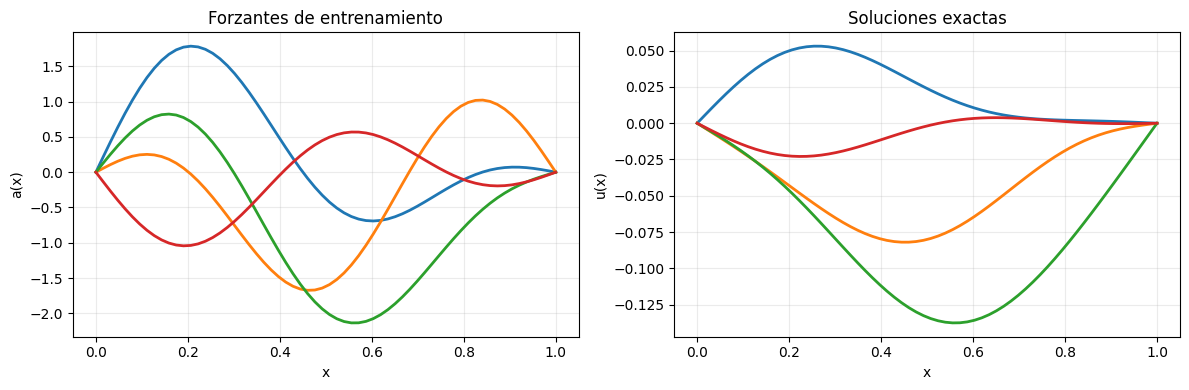

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for idx in range(4):
    axes[0].plot(x_grid, forcing_train[idx], lw=2)
    axes[1].plot(x_grid, solution_train[idx], lw=2)

axes[0].set_title("Forzantes de entrenamiento")
axes[0].set_xlabel("x")
axes[0].set_ylabel("a(x)")
axes[0].grid(alpha=0.25)

axes[1].set_title("Soluciones exactas")
axes[1].set_xlabel("x")
axes[1].set_ylabel("u(x)")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [5]:
class FeedForward(nn.Module):
    def __init__(self, in_shape, out_shape, n_hidden_layers=2, width=64, actfn="tanh"):
        super().__init__()
        activation_cls = {"tanh": nn.Tanh, "relu": nn.ReLU}[actfn]
        layers = []
        input_dim = in_shape
        for _ in range(n_hidden_layers):
            layers.append(nn.Linear(input_dim, width))
            layers.append(activation_cls())
            input_dim = width
        layers.append(nn.Linear(input_dim, out_shape))
        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.network(inputs)


class DeepONet(nn.Module):
    def __init__(self, n_sensors, latent_dim=32, n_hidden_layers=2, width=64):
        super().__init__()
        self.branch_net = FeedForward(n_sensors, latent_dim, n_hidden_layers, width)
        self.trunk_net = FeedForward(1, latent_dim, n_hidden_layers, width)
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, branch_inputs, query_points):
        branch_code = self.branch_net(branch_inputs)
        trunk_code = self.trunk_net(query_points)
        return branch_code @ trunk_code.T + self.bias


class SpectralConv1d(nn.Module):
    # Capa convolucional espectral 1D para FNO
    def __init__(self, in_channels, out_channels, modes):
        super().__init__()
        self.modes = modes  # Número de modos de Fourier a usar (baja frecuencia)
        scale = 1.0 / (in_channels * out_channels)
        # Pesos complejos aprendibles para cada modo y canal
        self.weights = nn.Parameter(
            scale * torch.randn(in_channels, out_channels, modes, dtype=torch.cfloat)
        )

    def forward(self, inputs):
        # 1. Transformada de Fourier real a compleja sobre la última dimensión (espacial)
        inputs_ft = torch.fft.rfft(inputs, dim=-1)
        # 2. Inicializa el tensor de salida en el espacio de Fourier (todo en cero)
        out_ft = torch.zeros(
            inputs.shape[0],                # batch size
            self.weights.shape[1],          # out_channels
            inputs.size(-1) // 2 + 1,       # número de frecuencias positivas
            dtype=torch.cfloat,
            device=inputs.device,
        )
        # 3. Multiplica los primeros 'modos' de la entrada por los pesos aprendidos
        #    (solo se modifican los modos de baja frecuencia)
        out_ft[:, :, : self.modes] = torch.einsum(
            "bim, iom -> bom",              # b: batch, i: in_channel, o: out_channel, m: modo
            inputs_ft[:, :, : self.modes],  # selecciona solo los primeros modos
            self.weights,
        )
        # 4. Transformada inversa de Fourier para volver al espacio físico
        return torch.fft.irfft(out_ft, n=inputs.size(-1), dim=-1)
    
class FNOBlock1d(nn.Module):
    def __init__(self, width, modes):
        super().__init__()
        self.spectral = SpectralConv1d(width, width, modes)
        self.pointwise = nn.Conv1d(width, width, kernel_size=1)

    def forward(self, inputs):
        return F.gelu(self.spectral(inputs) + self.pointwise(inputs))


class FNO1d(nn.Module):
    def __init__(self, modes=8, width=16, n_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(2, width)
        self.blocks = nn.ModuleList([FNOBlock1d(width, modes) for _ in range(n_layers)])
        self.output_proj = nn.Sequential(
            nn.Linear(width, 32),
            nn.GELU(),
            nn.Linear(32, 1),
        )

    def forward(self, forcing_values, x_grid_values):
        if x_grid_values.ndim == 1:
            x_grid_values = x_grid_values.unsqueeze(0).expand(forcing_values.size(0), -1)
        inputs = torch.stack([forcing_values, x_grid_values], dim=-1)
        hidden = self.input_proj(inputs).permute(0, 2, 1)
        for block in self.blocks:
            hidden = block(hidden)
        hidden = hidden.permute(0, 2, 1)
        return self.output_proj(hidden).squeeze(-1)


def describe_model(model):
    total_params = sum(parameter.numel() for parameter in model.parameters())
    print(model)
    print(f"Total parameters: {total_params}")


def evaluate_deeponet(model, forcing_values):
    model.eval()
    with torch.no_grad():
        forcing_t = torch.as_tensor(forcing_values, dtype=torch.get_default_dtype(), device=device)
        prediction = model(forcing_t, x_query) / output_scale
    return prediction.cpu().numpy()


def evaluate_fno(model, forcing_values):
    model.eval()
    with torch.no_grad():
        forcing_t = torch.as_tensor(forcing_values, dtype=torch.get_default_dtype(), device=device)
        prediction = model(forcing_t, x_grid_t)
    return prediction.cpu().numpy()


def trunk_with_second_derivative(trunk_net, query_points):
    trunk_code = trunk_net(query_points)
    trunk_xx = []
    for k in range(trunk_code.shape[1]):
        first = torch.autograd.grad(
            trunk_code[:, k].sum(),
            query_points,
            create_graph=True,
            retain_graph=True,
        )[0]
        second = torch.autograd.grad(
            first.sum(),
            query_points,
            create_graph=True,
            retain_graph=True,
        )[0]
        trunk_xx.append(second.squeeze(-1))
    return trunk_code, torch.stack(trunk_xx, dim=1)

## DeepONet

DeepONet representa el operador como una combinación separable:

$$
\mathcal{G}_\theta(a)(x) = \sum_{j=1}^p b_j(a(x_1), \dots, a(x_m))\, t_j(x) + b_0.
$$

- La **branch net** resume la función de entrada a través de sus muestras en sensores.
- La **trunk net** construye una base dependiente de la coordenada $x$.

Su sesgo inductivo es el de una aproximación **separable sensor-a-coordenada**. Eso la vuelve flexible para entradas irregulares o consultas fuera de la grilla de entrenamiento.

In [15]:
def train_deeponet_supervised(epochs=120, batch_size=64):
    model = DeepONet(n_sensors=n_grid).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-6)
    loader = DataLoader(
        TensorDataset(
            torch.from_numpy(forcing_train),
            torch.from_numpy(solution_train * output_scale),
        ),
        batch_size=batch_size,
        shuffle=True,
    )

    history = []
    start = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        n_examples = 0
        for forcing_batch, solution_batch in loader:
            forcing_batch = forcing_batch.to(device)
            solution_batch = solution_batch.to(device)
            optimizer.zero_grad()
            prediction = model(forcing_batch, x_query)
            loss = torch.mean((prediction - solution_batch) ** 2)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * forcing_batch.size(0)
            n_examples += forcing_batch.size(0)
        epoch_loss = running_loss / n_examples
        history.append(epoch_loss)
        if epoch % 40 == 0 or epoch == 1:
            print(f"DeepONet epoch {epoch:3d} | MSE {epoch_loss:.3e}")
    elapsed = time.time() - start
    return model, history, elapsed


deeponet_model, deeponet_history, deeponet_time = train_deeponet_supervised(epochs=600)
describe_model(deeponet_model)

DeepONet epoch   1 | MSE 7.127e-01
DeepONet epoch  40 | MSE 1.372e-02
DeepONet epoch  80 | MSE 4.233e-03
DeepONet epoch 120 | MSE 8.293e-04
DeepONet epoch 160 | MSE 6.072e-03
DeepONet epoch 200 | MSE 1.464e-03
DeepONet epoch 240 | MSE 1.196e-03
DeepONet epoch 280 | MSE 1.132e-03
DeepONet epoch 320 | MSE 1.507e-03
DeepONet epoch 360 | MSE 3.965e-04
DeepONet epoch 400 | MSE 1.145e-03
DeepONet epoch 440 | MSE 2.274e-04
DeepONet epoch 480 | MSE 8.166e-04
DeepONet epoch 520 | MSE 1.513e-03
DeepONet epoch 560 | MSE 6.778e-04
DeepONet epoch 600 | MSE 7.273e-04
DeepONet(
  (branch_net): FeedForward(
    (network): Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=32, bias=True)
    )
  )
  (trunk_net): FeedForward(
    (network): Sequential(
      (0): Linear(in_features=1, out_features=64, bias=True)
      (1): Tanh()
      (2

## Comparacion in-distribution y extrapolacion

Vamos a evaluar tres conjuntos:

- **Validacion**: mismos modos y amplitudes que en entrenamiento.
- **Amplitude OOD**: mismos modos, pero con coeficientes mas grandes.
- **Frequency OOD**: aparece un cuarto modo sinusoidal que no estaba en entrenamiento.

Este ultimo test es importante: extrapolar a una frecuencia nueva no es lo mismo que extrapolar a una amplitud nueva.

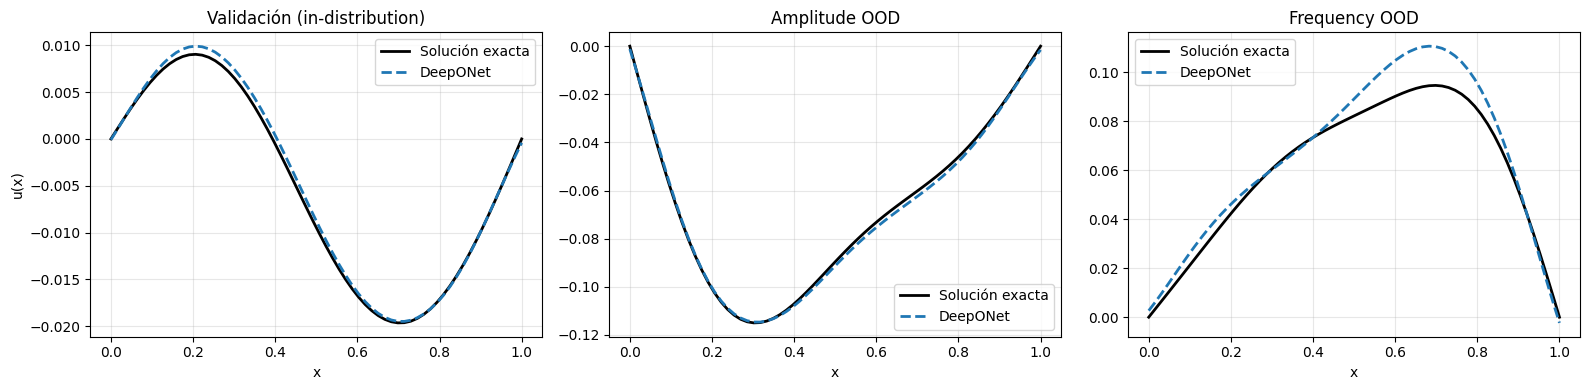

In [16]:
coeff_amp = coeficientes_muestra(64, train_modes, low=-2.2, high=2.2)
forcing_amp = fuerza_desde_coefs(coeff_amp, x_grid, train_modes)
solution_amp = solucion_desde_coefs(coeff_amp, x_grid, train_modes)

freq_modes = np.arange(1, 5, dtype=np.float32)
coeff_freq = coeficientes_muestra(64, freq_modes, low=-1.25, high=1.25)
forcing_freq = fuerza_desde_coefs(coeff_freq, x_grid, freq_modes)
solution_freq = solucion_desde_coefs(coeff_freq, x_grid, freq_modes)

pred_val_deep = evaluate_deeponet(deeponet_model, forcing_val)
pred_amp_deep = evaluate_deeponet(deeponet_model, forcing_amp)
pred_freq_deep = evaluate_deeponet(deeponet_model, forcing_freq)

# Graficar resultados de DeepONet entrenada
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Ejemplo de validación
example_id = 0
axes[0].plot(x_grid, solution_val[example_id], label="Solución exacta", color="black", lw=2)
axes[0].plot(x_grid, pred_val_deep[example_id], "--", label="DeepONet", color="tab:blue", lw=2)
axes[0].set_title("Validación (in-distribution)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Ejemplo Amplitude OOD
example_amp = 1
axes[1].plot(x_grid, solution_amp[example_amp], label="Solución exacta", color="black", lw=2)
axes[1].plot(x_grid, pred_amp_deep[example_amp], "--", label="DeepONet", color="tab:blue", lw=2)
axes[1].set_title("Amplitude OOD")
axes[1].set_xlabel("x")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Ejemplo Frequency OOD
example_freq = 2
axes[2].plot(x_grid, solution_freq[example_freq], label="Solución exacta", color="black", lw=2)
axes[2].plot(x_grid, pred_freq_deep[example_freq], "--", label="DeepONet", color="tab:blue", lw=2)
axes[2].set_title("Frequency OOD")
axes[2].set_xlabel("x")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Tras entrenar la arquitectura **DeepONet** sobre el problema de Poisson 1D, observamos lo siguiente:

- El modelo logra aprender el operador que mapea la función de entrada $a(x)$ a la solución $u(x)$ con buen desempeño en el conjunto de validación, mostrando errores relativos bajos cuando las funciones de entrada pertenecen a la misma familia que las vistas en entrenamiento.
- DeepONet es flexible y puede evaluar la solución en cualquier punto $x$, no solo en la grilla de entrenamiento, gracias a su estructura separable `branch/trunk`.
- En escenarios de extrapolación, como amplitudes fuera del rango de entrenamiento (**Amplitude OOD**) o la aparición de nuevas frecuencias (**Frequency OOD**), el error aumenta, especialmente cuando se introduce un modo no visto durante el entrenamiento.
- El tiempo de entrenamiento y la cantidad de parámetros son razonables para este tipo de problemas, y la arquitectura es robusta para entradas irregulares o consultas fuera de la grilla.

En resumen, DeepONet es una herramienta poderosa para aprender operadores en problemas donde la entrada y la salida son funciones, destacándose por su capacidad de generalización espacial y su flexibilidad estructural.

## FNO

La **Fourier Neural Operator** trabaja directamente sobre una grilla fija. Cada bloque mezcla dos efectos:

- una transformación global en Fourier, que actúa sobre un número pequeño de modos bajos;
- una capa local punto a punto, que corrige lo que no queda capturado por la parte espectral.

Su sesgo inductivo es naturalmente **espectral y grid-based**. Cuando la dinámica del operador está bien representada por modos suaves sobre una grilla regular, suele aprender con muy pocos parámetros efectivos.

In [17]:
def train_fno_supervised(epochs=80, batch_size=64):
    model = FNO1d().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-6)
    loader = DataLoader(
        TensorDataset(
            torch.from_numpy(forcing_train),
            torch.from_numpy(solution_train),
        ),
        batch_size=batch_size,
        shuffle=True,
    )

    history = []
    start = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        n_examples = 0
        for forcing_batch, solution_batch in loader:
            forcing_batch = forcing_batch.to(device)
            solution_batch = solution_batch.to(device)
            optimizer.zero_grad()
            prediction = model(forcing_batch, x_grid_t)
            loss = torch.mean((prediction - solution_batch) ** 2)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * forcing_batch.size(0)
            n_examples += forcing_batch.size(0)
        epoch_loss = running_loss / n_examples
        history.append(epoch_loss)
        if epoch % 20 == 0 or epoch == 1:
            print(f"FNO epoch {epoch:3d} | MSE {epoch_loss:.3e}")
    elapsed = time.time() - start
    return model, history, elapsed


fno_model, fno_history, fno_time = train_fno_supervised(epochs=600)
describe_model(fno_model)

FNO epoch   1 | MSE 2.119e-02
FNO epoch  20 | MSE 6.378e-06
FNO epoch  40 | MSE 2.382e-06
FNO epoch  60 | MSE 1.590e-06
FNO epoch  80 | MSE 1.211e-06
FNO epoch 100 | MSE 1.014e-06
FNO epoch 120 | MSE 8.776e-07
FNO epoch 140 | MSE 8.113e-07
FNO epoch 160 | MSE 7.608e-07
FNO epoch 180 | MSE 7.206e-07
FNO epoch 200 | MSE 6.568e-07
FNO epoch 220 | MSE 7.090e-07
FNO epoch 240 | MSE 6.707e-07
FNO epoch 260 | MSE 6.281e-07
FNO epoch 280 | MSE 6.098e-07
FNO epoch 300 | MSE 6.119e-07
FNO epoch 320 | MSE 5.625e-07
FNO epoch 340 | MSE 5.437e-07
FNO epoch 360 | MSE 5.731e-07
FNO epoch 380 | MSE 5.546e-07
FNO epoch 400 | MSE 8.537e-07
FNO epoch 420 | MSE 5.142e-07
FNO epoch 440 | MSE 7.774e-07
FNO epoch 460 | MSE 8.709e-07
FNO epoch 480 | MSE 4.893e-07
FNO epoch 500 | MSE 5.258e-07
FNO epoch 520 | MSE 6.746e-07
FNO epoch 540 | MSE 1.282e-06
FNO epoch 560 | MSE 1.619e-06
FNO epoch 580 | MSE 5.264e-07
FNO epoch 600 | MSE 6.267e-07
FNO1d(
  (input_proj): Linear(in_features=2, out_features=16, bias=Tru

Misma comparación que antes pero para ambas redes

In [18]:
coeff_amp = coeficientes_muestra(64, train_modes, low=-2.2, high=2.2)
forcing_amp = fuerza_desde_coefs(coeff_amp, x_grid, train_modes)
solution_amp = solucion_desde_coefs(coeff_amp, x_grid, train_modes)

freq_modes = np.arange(1, 5, dtype=np.float32)
coeff_freq = coeficientes_muestra(64, freq_modes, low=-1.25, high=1.25)
forcing_freq = fuerza_desde_coefs(coeff_freq, x_grid, freq_modes)
solution_freq = solucion_desde_coefs(coeff_freq, x_grid, freq_modes)

pred_val_deep = evaluate_deeponet(deeponet_model, forcing_val)
pred_amp_deep = evaluate_deeponet(deeponet_model, forcing_amp)
pred_freq_deep = evaluate_deeponet(deeponet_model, forcing_freq)

pred_val_fno = evaluate_fno(fno_model, forcing_val)
pred_amp_fno = evaluate_fno(fno_model, forcing_amp)
pred_freq_fno = evaluate_fno(fno_model, forcing_freq)

comparison_df = pd.DataFrame(
    [
        {
            "modelo": "DeepONet",
            "tiempo_entrenamiento_s": deeponet_time,
            "val_relL2": relative_l2(pred_val_deep, solution_val).mean(),
            "amp_ood_relL2": relative_l2(pred_amp_deep, solution_amp).mean(),
            "freq_ood_relL2": relative_l2(pred_freq_deep, solution_freq).mean(),
        },
        {
            "modelo": "FNO",
            "tiempo_entrenamiento_s": fno_time,
            "val_relL2": relative_l2(pred_val_fno, solution_val).mean(),
            "amp_ood_relL2": relative_l2(pred_amp_fno, solution_amp).mean(),
            "freq_ood_relL2": relative_l2(pred_freq_fno, solution_freq).mean(),
        },
    ]
)
comparison_df.round(4)

,modelo,tiempo_entrenamiento_s,val_relL2,amp_ood_relL2,freq_ood_relL2
0,DeepONet,6.1406,0.0234,0.0608,0.3448
1,FNO,51.2920,0.0242,0.0342,0.0882


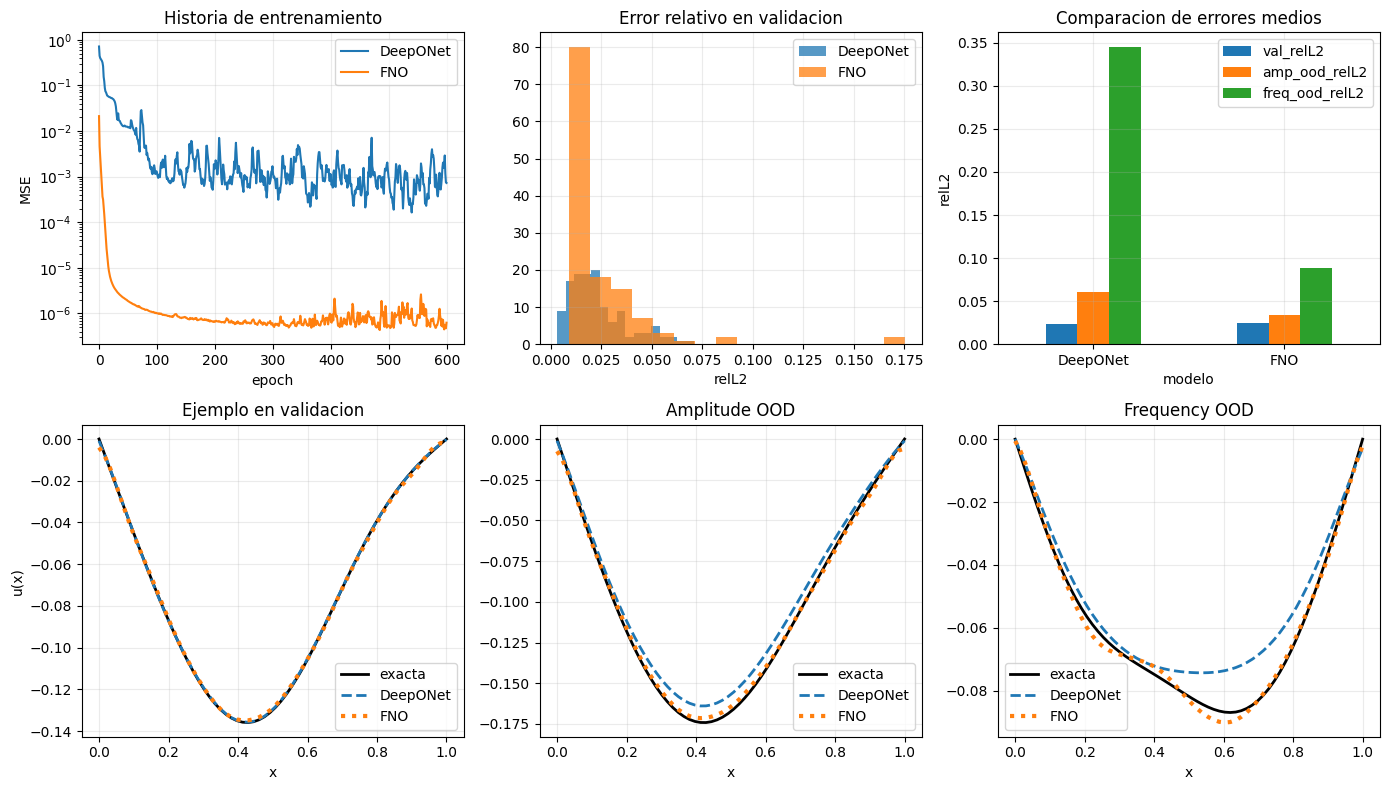

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].semilogy(deeponet_history, label="DeepONet")
axes[0, 0].semilogy(fno_history, label="FNO")
axes[0, 0].set_title("Historia de entrenamiento")
axes[0, 0].set_xlabel("epoch")
axes[0, 0].set_ylabel("MSE")
axes[0, 0].grid(alpha=0.25)
axes[0, 0].legend()

val_errors_deep = relative_l2(pred_val_deep, solution_val)
val_errors_fno = relative_l2(pred_val_fno, solution_val)
axes[0, 1].hist(val_errors_deep, bins=16, alpha=0.75, label="DeepONet")
axes[0, 1].hist(val_errors_fno, bins=16, alpha=0.75, label="FNO")
axes[0, 1].set_title("Error relativo en validacion")
axes[0, 1].set_xlabel("relL2")
axes[0, 1].grid(alpha=0.25)
axes[0, 1].legend()

metrics = comparison_df.set_index("modelo")[["val_relL2", "amp_ood_relL2", "freq_ood_relL2"]]
metrics.plot(kind="bar", ax=axes[0, 2], rot=0)
axes[0, 2].set_title("Comparacion de errores medios")
axes[0, 2].set_ylabel("relL2")
axes[0, 2].grid(alpha=0.25)

example_id = 4
axes[1, 0].plot(x_grid, solution_val[example_id], color="black", lw=2, label="exacta")
axes[1, 0].plot(x_grid, pred_val_deep[example_id], "--", lw=2, label="DeepONet")
axes[1, 0].plot(x_grid, pred_val_fno[example_id], ":", lw=3, label="FNO")
axes[1, 0].set_title("Ejemplo en validacion")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("u(x)")
axes[1, 0].grid(alpha=0.25)
axes[1, 0].legend()

example_amp = 2
axes[1, 1].plot(x_grid, solution_amp[example_amp], color="black", lw=2, label="exacta")
axes[1, 1].plot(x_grid, pred_amp_deep[example_amp], "--", lw=2, label="DeepONet")
axes[1, 1].plot(x_grid, pred_amp_fno[example_amp], ":", lw=3, label="FNO")
axes[1, 1].set_title("Amplitude OOD")
axes[1, 1].set_xlabel("x")
axes[1, 1].grid(alpha=0.25)
axes[1, 1].legend()

example_freq = 1
axes[1, 2].plot(x_grid, solution_freq[example_freq], color="black", lw=2, label="exacta")
axes[1, 2].plot(x_grid, pred_freq_deep[example_freq], "--", lw=2, label="DeepONet")
axes[1, 2].plot(x_grid, pred_freq_fno[example_freq], ":", lw=3, label="FNO")
axes[1, 2].set_title("Frequency OOD")
axes[1, 2].set_xlabel("x")
axes[1, 2].grid(alpha=0.25)
axes[1, 2].legend()

plt.tight_layout()
plt.show()

En este problema, sobre una grilla uniforme fija, la **FNO** suele salir favorecida por dos razones:

- su sesgo inductivo es espectral y global, muy alineado con una familia de soluciones suaves escritas en senos;
- la arquitectura comparte pesos a lo largo de la grilla, lo que reduce la carga estadistica del aprendizaje.

DeepONet, por su parte, mantiene ventajas conceptuales importantes:

- separa claramente el procesamiento de la función de entrada y de la coordenada de consulta;
- puede evaluarse en puntos continuos $x$ si entrenamos una `trunk` adecuada;
- no necesita que la entrada llegue en una malla estrictamente regular.

La extrapolación también muestra dos regimens distintos:

- **amplitud nueva**: ambos modelos se degradan, pero FNO degrada menos en esta configuracion;
- **frecuencia nueva**: agregar un modo no visto es bastante mas dificil que cambiar amplitudes, y ahi aparece con claridad el límite de la extrapolación estructural.

## Physics-informed operator learning con pocos datos

Ahora cambiamos el escenario: suponemos que solo tenemos **64 pares supervisados** $(a_i, u_i)$, pero seguimos conociendo la PDE.

La idea es entrenar un operador neural con una perdida mixta:

$$
\mathcal{L} = \mathcal{L}_{\mathrm{sup}} + \lambda_{\mathrm{phys}}\, \mathcal{L}_{\mathrm{PDE}} + \lambda_{\mathrm{bc}}\, \mathcal{L}_{\mathrm{BC}}.
$$

Usaremos **DeepONet** para esta parte porque su `trunk` depende de la coordenada continua $x$, de modo que podemos derivarla dos veces con autograd y construir el residual

$$
R(x) = -u_{xx}(x) - a(x).
$$

La pregunta no es si supera al mejor modelo completamente supervisado, sino si **reduce la necesidad de datos**.

In [24]:
def train_deeponet_low_data(epochs=120, batch_size=32):
    model = DeepONet(n_sensors=n_grid).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-6)
    loader = DataLoader(
        TensorDataset(
            torch.from_numpy(forcing_train[:64]),
            torch.from_numpy(solution_train[:64] * output_scale),
        ),
        batch_size=batch_size,
        shuffle=True,
    )

    history = []
    start = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        n_examples = 0
        for forcing_batch, solution_batch in loader:
            forcing_batch = forcing_batch.to(device)
            solution_batch = solution_batch.to(device)
            optimizer.zero_grad()
            prediction = model(forcing_batch, x_query)
            loss = torch.mean((prediction - solution_batch) ** 2)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * forcing_batch.size(0)
            n_examples += forcing_batch.size(0)
        history.append(running_loss / n_examples)
    elapsed = time.time() - start
    return model, history, elapsed


def train_pi_deeponet(epochs=120, batch_size=16, lambda_phys=0.05, lambda_bc=5.0):
    model = DeepONet(n_sensors=n_grid).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-6)
    labeled_loader = DataLoader(
        TensorDataset(
            torch.from_numpy(forcing_train[:64]),
            torch.from_numpy(solution_train[:64] * output_scale),
        ),
        batch_size=batch_size,
        shuffle=True,
    )
    all_forcing_t = torch.from_numpy(forcing_train).to(device)

    history = {"data": [], "physics": [], "total": []}
    start = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        data_running = 0.0
        phys_running = 0.0
        total_running = 0.0
        n_examples = 0

        for forcing_batch, solution_batch in labeled_loader:
            forcing_batch = forcing_batch.to(device)
            solution_batch = solution_batch.to(device)
            optimizer.zero_grad()

            supervised_prediction = model(forcing_batch, x_query)
            loss_data = torch.mean((supervised_prediction - solution_batch) ** 2)

            physics_idx = torch.randint(0, all_forcing_t.size(0), (batch_size,), device=device)
            forcing_phys = all_forcing_t[physics_idx]
            query_phys = x_query.clone().detach().requires_grad_(True)
            trunk_code, trunk_xx = trunk_with_second_derivative(model.trunk_net, query_phys)
            branch_code = model.branch_net(forcing_phys)
            pred_phys = branch_code @ trunk_code.T + model.bias
            pred_xx = branch_code @ trunk_xx.T

            residual = -(pred_xx / output_scale) - forcing_phys
            loss_phys = torch.mean(residual[:, 1:-1] ** 2)
            loss_bc = torch.mean((pred_phys[:, [0, -1]] / output_scale) ** 2)

            loss = loss_data + lambda_phys * loss_phys + lambda_bc * loss_bc
            loss.backward()
            optimizer.step()

            data_running += loss_data.item() * forcing_batch.size(0)
            phys_running += loss_phys.item() * forcing_batch.size(0)
            total_running += loss.item() * forcing_batch.size(0)
            n_examples += forcing_batch.size(0)

        history["data"].append(data_running / n_examples)
        history["physics"].append(phys_running / n_examples)
        history["total"].append(total_running / n_examples)
        if epoch % 40 == 0 or epoch == 1:
            print(
                f"PI-DeepONet epoch {epoch:3d} | data {history['data'][-1]:.3e} | physics {history['physics'][-1]:.3e}"
            )

    elapsed = time.time() - start
    return model, history, elapsed


low_data_model, low_data_history, low_data_time = train_deeponet_low_data(epochs=600)
pi_model, pi_history, pi_time = train_pi_deeponet(epochs=600)

PI-DeepONet epoch   1 | data 1.171e+00 | physics 8.275e-01
PI-DeepONet epoch  40 | data 5.524e-02 | physics 5.283e-01
PI-DeepONet epoch  80 | data 2.560e-02 | physics 1.325e-01
PI-DeepONet epoch 120 | data 7.212e-03 | physics 2.666e-02
PI-DeepONet epoch 160 | data 7.212e-03 | physics 2.600e-02
PI-DeepONet epoch 200 | data 4.724e-03 | physics 1.391e-02
PI-DeepONet epoch 240 | data 2.199e-03 | physics 1.391e-02
PI-DeepONet epoch 280 | data 4.707e-03 | physics 1.431e-02
PI-DeepONet epoch 320 | data 1.280e-02 | physics 2.595e-02
PI-DeepONet epoch 360 | data 8.308e-03 | physics 1.371e-02
PI-DeepONet epoch 400 | data 5.145e-03 | physics 9.207e-03
PI-DeepONet epoch 440 | data 2.245e-03 | physics 8.956e-03
PI-DeepONet epoch 480 | data 3.467e-03 | physics 1.090e-02
PI-DeepONet epoch 520 | data 7.338e-03 | physics 1.191e-02
PI-DeepONet epoch 560 | data 4.424e-03 | physics 9.646e-03
PI-DeepONet epoch 600 | data 3.057e-03 | physics 7.600e-03


In [25]:
pred_val_low = evaluate_deeponet(low_data_model, forcing_val)
pred_val_pi = evaluate_deeponet(pi_model, forcing_val)

pred_amp_low = evaluate_deeponet(low_data_model, forcing_amp)
pred_amp_pi = evaluate_deeponet(pi_model, forcing_amp)

pred_freq_low = evaluate_deeponet(low_data_model, forcing_freq)
pred_freq_pi = evaluate_deeponet(pi_model, forcing_freq)

low_data_df = pd.DataFrame(
    [
        {
            "modelo": "DeepONet (64 etiquetas)",
            "tiempo_entrenamiento_s": low_data_time,
            "val_relL2": relative_l2(pred_val_low, solution_val).mean(),
            "amp_ood_relL2": relative_l2(pred_amp_low, solution_amp).mean(),
            "freq_ood_relL2": relative_l2(pred_freq_low, solution_freq).mean(),
        },
        {
            "modelo": "PI-DeepONet (64 etiquetas + residual)",
            "tiempo_entrenamiento_s": pi_time,
            "val_relL2": relative_l2(pred_val_pi, solution_val).mean(),
            "amp_ood_relL2": relative_l2(pred_amp_pi, solution_amp).mean(),
            "freq_ood_relL2": relative_l2(pred_freq_pi, solution_freq).mean(),
        },
    ]
)
low_data_df.round(4)

,modelo,tiempo_entrenamiento_s,val_relL2,amp_ood_relL2,freq_ood_relL2
0,DeepONet (64 etiquetas),1.2813,0.0567,0.1148,0.1248
1,PI-DeepONet (64 etiquetas + residual),34.9187,0.0574,0.1074,0.2716


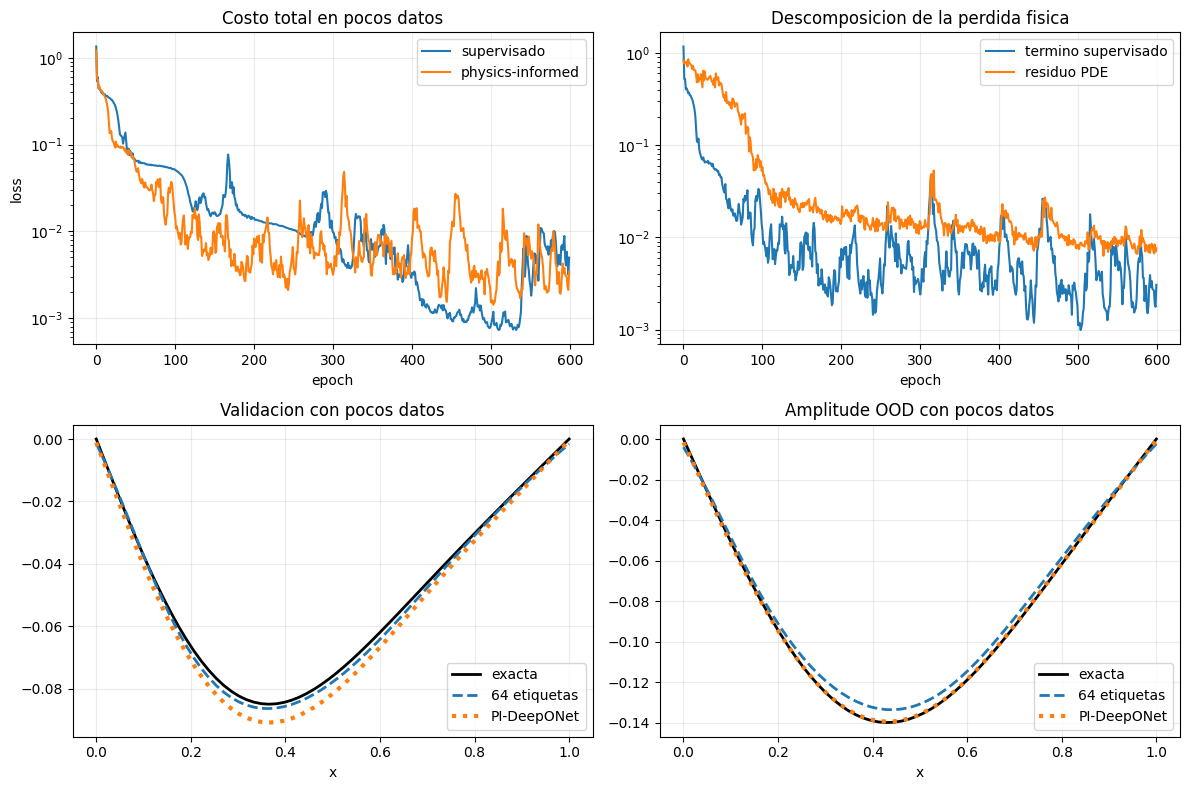

,modelo,tiempo_entrenamiento_s,val_relL2,amp_ood_relL2,freq_ood_relL2
0,DeepONet (64 etiquetas),1.2813,0.0567,0.1148,0.1248
1,PI-DeepONet (64 etiquetas + residual),34.9187,0.0574,0.1074,0.2716


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].semilogy(low_data_history, label="supervisado")
axes[0, 0].semilogy(pi_history["total"], label="physics-informed")
axes[0, 0].set_title("Costo total en pocos datos")
axes[0, 0].set_xlabel("epoch")
axes[0, 0].set_ylabel("loss")
axes[0, 0].grid(alpha=0.25)
axes[0, 0].legend()

axes[0, 1].semilogy(pi_history["data"], label="termino supervisado")
axes[0, 1].semilogy(pi_history["physics"], label="residuo PDE")
axes[0, 1].set_title("Descomposicion de la perdida fisica")
axes[0, 1].set_xlabel("epoch")
axes[0, 1].grid(alpha=0.25)
axes[0, 1].legend()

example_small = 2
axes[1, 0].plot(x_grid, solution_val[example_small], color="black", lw=2, label="exacta")
axes[1, 0].plot(x_grid, pred_val_low[example_small], "--", lw=2, label="64 etiquetas")
axes[1, 0].plot(x_grid, pred_val_pi[example_small], ":", lw=3, label="PI-DeepONet")
axes[1, 0].set_title("Validacion con pocos datos")
axes[1, 0].set_xlabel("x")
axes[1, 0].grid(alpha=0.25)
axes[1, 0].legend()

example_amp = 5
axes[1, 1].plot(x_grid, solution_amp[example_amp], color="black", lw=2, label="exacta")
axes[1, 1].plot(x_grid, pred_amp_low[example_amp], "--", lw=2, label="64 etiquetas")
axes[1, 1].plot(x_grid, pred_amp_pi[example_amp], ":", lw=3, label="PI-DeepONet")
axes[1, 1].set_title("Amplitude OOD con pocos datos")
axes[1, 1].set_xlabel("x")
axes[1, 1].grid(alpha=0.25)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

low_data_df.round(4)

## Conclusión

Este ejemplo deja tres mensajes prácticos:

1. **DeepONet y FNO aprenden operadores, no soluciones puntuales.**
2. **El sesgo inductivo importa**: en una grilla regular y con soluciones suaves dominadas por pocos modos, la FNO fue mas eficiente y extrapoló mejor.
3. **La fisica ayuda sobre todo cuando faltan etiquetas**: el esquema `PI-DeepONet` mejoró claramente el error de validación y la extrapolación en amplitud frente a un DeepONet entrenado con solo 64 ejemplos supervisados.

También aparece un límite importante: imponer la PDE no garantiza extrapolar a estructuras que no estaban en la familia de entrenamiento. En particular, introducir un modo espacial nuevo sigue siendo un problema mas duro que simplemente cambiar la amplitud.